# Index check

This notebook looks at the index hack that I have used in the numerical mixing diagnostic.

## Background

I got stuck on the numerical mixing diagnostic for a very long time with it always producing output that was wrong.
Eventually, I saved the west and east values that I was accessing in `T_adx` and `uhtr` separately to compare to what was saved if the diagnostic is explicitly saved.
I found the indexing for `T_adx` lined up but the `uhtr` variable did not; it was shifted by one.
Once this was adjusted in the numerical mixing diagnostic, the output looked correct.

I have now written separate "diagnostics" to save the west and east u point values at each grid cell so that I have something to show to other people as a kind of mwe.
I save the standard diagnostic as well two other versions with `_wu` and `_eu` appended to indicate I have saved the west and east u points, respectively.
The saving is designed such that `_wu` corresponds to `1:end-1` and `_eu` corresponds to `2:end` in terms of indexing along the x direction.
This means I should have exact equality between

```julia
var[1:end-1, :, :, :] .== var_wu[:, :, :, :]
var[2:end, :, :, :] .== var_eu[:, :, :, :]
```

where `var` is a model variable saved on `u`-points and `var_wu` and`var_eu` are as described above.

## The fix

Fortran index is sometimes tricky!
Thanks to help from Angus, the change was to remove assuming the shape of the arrays. So change to

```fortran
real,  dimension(SZIB_(G),SZJ_(G),SZK_(GV)), intent(in) :: uhtr !< the variable to save the east faces of
real, dimension(SZI_(G),SZJ_(G),SZK_(GV)), intent(inout) :: uhtr_eu !< The east u point value of `var`
real, dimension(SZI_(G),SZJ_(G),SZK_(GV)), intent(inout) :: uhtr_wu !< The west u point value of `var`
```

instead of using e.g. `uhtr(:,:,:)`. After this the indexing logic above works with `uhtr` which should mean it can go straight in to the rest of the code.
At this stage I will just change the `uhtr` variable because the `ad_x` one still works.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
hy_grid_check_dir = joinpath(tub_output_dir, "hycom-grid-checks")
if pwd() != hy_grid_check_dir
    cd(hy_grid_check_dir)
end
include("../plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [2]:
# output = joinpath(pwd(), "anu-tub-nm-zstar-idxcheck", "output443", "ocean_hour.nc")
# output = joinpath(pwd(), "anu-tub-nm-zstar-idxcheck-fixed-nm", "output443", "ocean_hour.nc")
# output = joinpath(pwd(), "anu-tub-nm-zstar-nm-check", "output443", "ocean_hour.nc") # a dummy directory I use for quick checks to make sure numerical mixing is not brokedn
output = joinpath(pwd(), "anu-tub-nm-zstar", "output443", "ocean_hour.nc") # any temporary run to quickly check numerical mixing

"/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-zstar/output443/ocean_hour.nc"

## `T_adx`

In [3]:
ds = NCDataset(output, maskingvalue = NaN)

T_adx = ds["T_adx"][:, :, :, :]
find_nan = .!isnan.(T_adx)
T_adx .*= find_nan
T_adx_wu = ds["T_adx_wu"][:, :, :, :]
find_nan = .!isnan.(T_adx_wu)
T_adx_wu .*= find_nan
T_adx_eu = ds["T_adx_eu"][:, :, :, :]
find_nan = .!isnan.(T_adx_eu)
T_adx_eu .*= find_nan

close(ds)

closed Dataset

In [4]:
all(T_adx[1:end-1, :, :, :] .== T_adx_wu)

true

In [5]:
all(T_adx[2:end, :, :, :] .== T_adx_eu)

true

Can see with `T_adx`, the logic described above works as expected: the west upoints are `1:end-1` and the east upoints are `2:end`.

## `uhtr`

In [6]:
ds = NCDataset(output, maskingvalue = NaN)

uhtr = ds["uhtr"][:, :, :, :]
find_nan = .!isnan.(uhtr)
uhtr .*= find_nan
uhtr_wu = ds["uhtr_wu"][:, :, :, :]
find_nan = .!isnan.(uhtr_wu)
uhtr_wu .*= find_nan
uhtr_eu = ds["uhtr_eu"][:, :, :, :]
find_nan = .!isnan.(uhtr_eu)
uhtr_eu .*= find_nan

close(ds)

closed Dataset

In [7]:
all(uhtr[1:end-1, :, :, :] .== uhtr_wu)

true

In [8]:
all(uhtr[2:end, :, :, :] .== uhtr_eu)

true

Here, this logic does not hold *until the fix is applied*.

In [9]:
all(uhtr[1:end-1, :, :, :] .== uhtr_eu)

false

does hold.
This is what led to the hack in the numerical mixing code and what I need to get input on.

## Numerical mixing

In [11]:
ds = NCDataset(output, maskingvalue = NaN)

nm = mean(nansum(ds["T_numerical_mixing"][:, :, :, :], dims = 3), dims = 4)[:, :, 1, 1]
nmzm = mean(nanmean(ds["T_numerical_mixing"][:, :, :, :], dims = 1), dims = 4)[1, :, :, 1]
close(ds)

closed Dataset

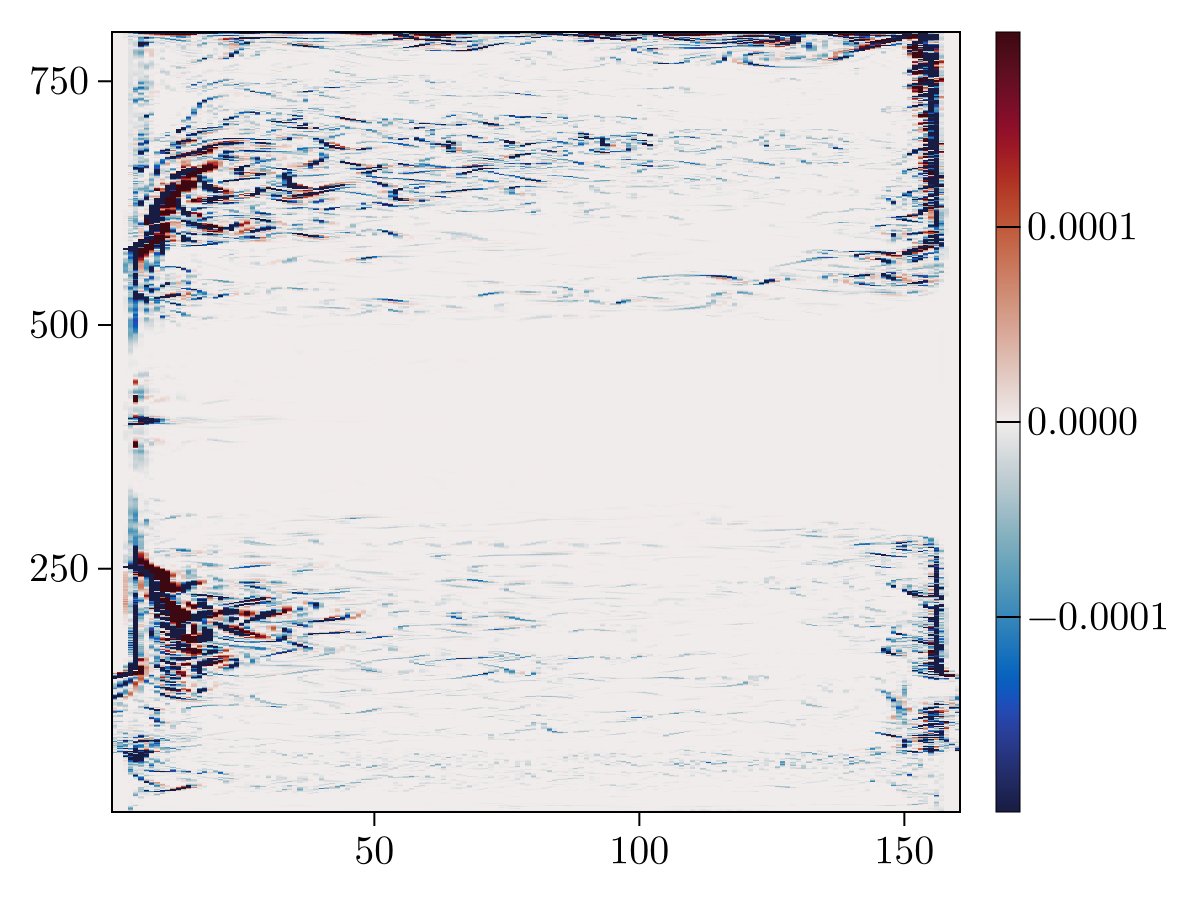

In [4]:
fig, ax, hm = heatmap(nm, colormap = :balance, colorrange = (-2e-4, 2e-4))
Colorbar(fig[1, 2], hm)
fig

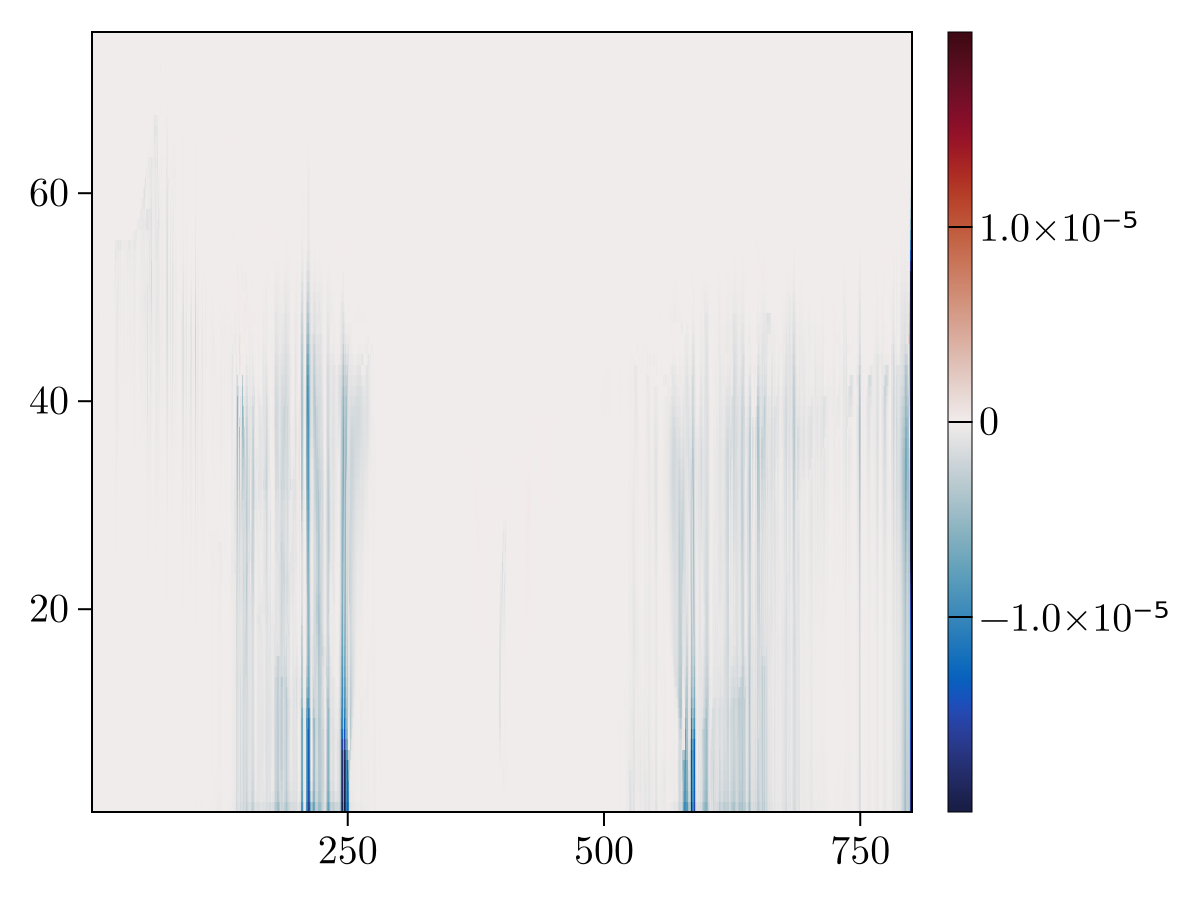

In [14]:
fig, ax, hm = heatmap(nmzm, colormap = :balance, colorrange = (-2e-5, 2e-5))
Colorbar(fig[1, 2], hm)
fig